# Support Vector Machine

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

## Importing the Data

In [2]:
data = pd.read_csv('/workspaces/Supervised-Machine-Learning/Datasets/Social_Network_Ads.csv')

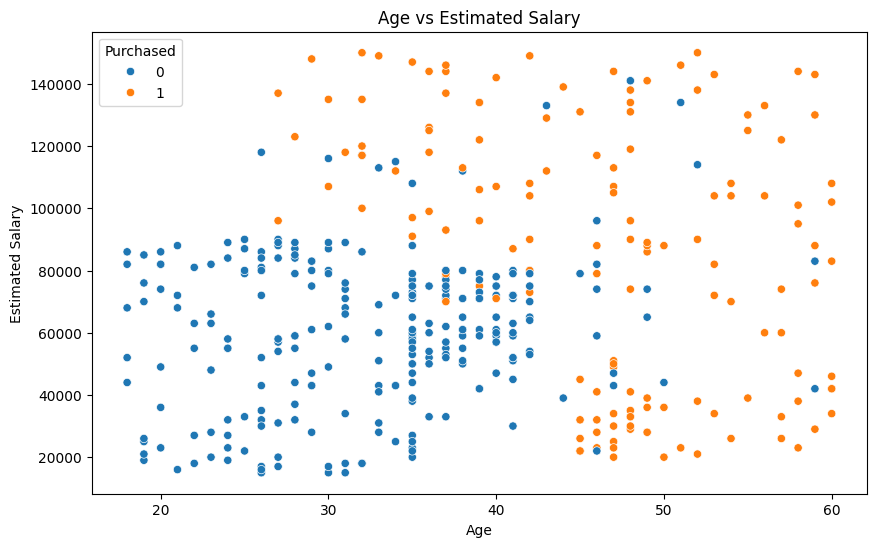

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['Age'], y=data['EstimatedSalary'], hue=data['Purchased'])
plt.title('Age vs Estimated Salary')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(title='Purchased')
plt.show()

In [4]:
X = data.iloc[:, [0, 1]].values
y = data.iloc[:, 2].values

## Splitting the Dataset

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 2421)

## Feature Scaling (Robust Scalar)

In [6]:
from sklearn.preprocessing import RobustScaler
sc = RobustScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training with RBF kernel

In [25]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 24, gamma=0.2, C=1)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.2
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


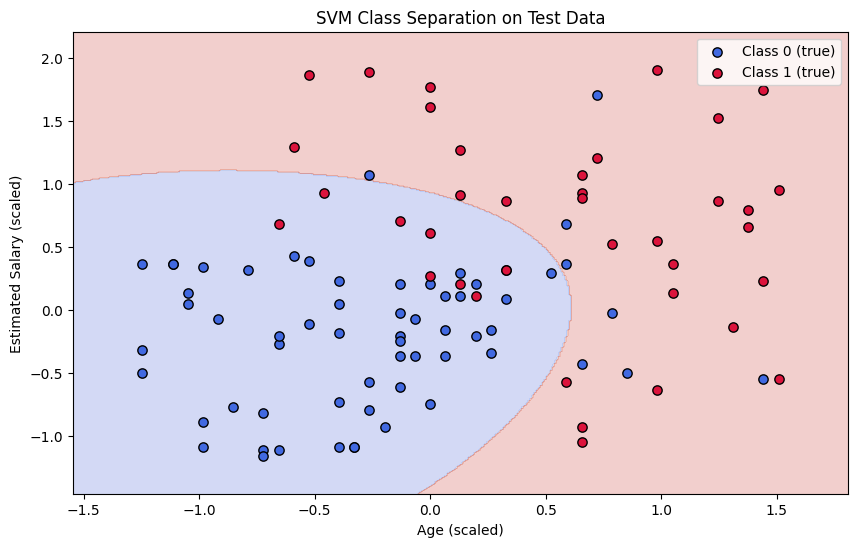

In [8]:
x1_min, x1_max = X_test[:, 0].min() - 0.3, X_test[:, 0].max() + 0.3
x2_min, x2_max = X_test[:, 1].min() - 0.3, X_test[:, 1].max() + 0.3

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 400),
    np.linspace(x2_min, x2_max, 400)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]
Z = classifier.predict(grid).reshape(xx1.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx1, xx2, Z, alpha=0.25, cmap=plt.cm.coolwarm)

for cls, color in zip([0, 1], ["royalblue", "crimson"]):
    mask = y_test == cls
    plt.scatter(
        X_test[mask, 0], X_test[mask, 1],
        c=color, label=f"Class {cls} (true)", edgecolor="k", s=45
    )

plt.title("SVM Class Separation on Test Data")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

svc = SVC(random_state=24)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [i/20 for i in range(1, 21)],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3, 4, 5]
}
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [27]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits
[CV] END ............C=0.1, degree=2, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.05, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.05, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.05, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.05, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.05, kernel=poly; total time=   0.0s
[CV] END .............C=0.1, degree=2, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .............C=0.1, degree=2, gamma=

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=24)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'gamma': [0.05, 0.1, ...], 'kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [28]:
from sklearn.metrics import classification_report

best_param = grid_search.best_params_
best_estimator = grid_search.best_estimator_
best_score = grid_search.best_score_

print("Best Parameters:", best_param)
print("Best Cross-Validation Score:", best_score)

print("Classification Report for Best Estimator:")
y_pred = best_estimator.predict(X_test)
print(classification_report(y_test, y_pred))

Best Parameters: {'C': 10, 'degree': 2, 'gamma': 0.35, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.93
Classification Report for Best Estimator:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87        62
           1       0.78      0.82      0.79        38

    accuracy                           0.84       100
   macro avg       0.83      0.84      0.83       100
weighted avg       0.84      0.84      0.84       100



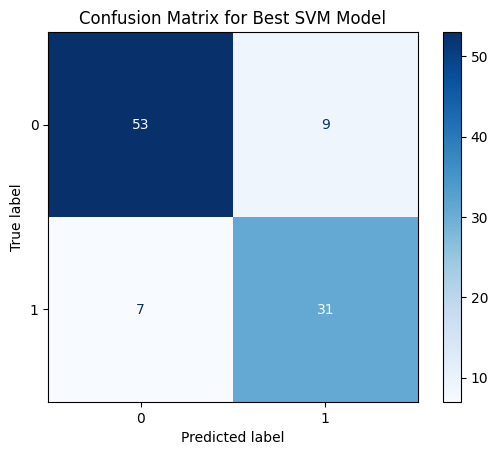

Test Accuracy: 0.8400


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_estimator.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Best SVM Model")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")